# QR Empirical Analysis

This notebook builds the Queue-Reactive empirical feature tables from `data/processed/FGBL_event_flow.parquet` without modifying LOB reconstruction or QR logic. It reproduces the intensity-vs-queue-size curves and the first-half vs second-half stability comparison.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.qr_empirical import build_qr_intensity_tables

In [ ]:
curves_df, size_curves_df, diagnostics_df, aes = build_qr_intensity_tables(
    event_flow_path=str(ROOT / "data/processed/FGBL_event_flow.parquet"),
    output_path=str(ROOT / "data/processed/qr_intensities.parquet"),
    size_output_path=str(ROOT / "data/processed/qr_intensities_size.parquet"),
    raw_dir=str(ROOT / "data/raw"),
    level=1,
    min_obs=50, 
)

full_curves = curves_df[(curves_df["segment"] == "full_month") & (curves_df["estimator"] == "state_duration")].copy()
first_curves = curves_df[(curves_df["segment"] == "first_half") & (curves_df["estimator"] == "state_duration")].copy()
second_curves = curves_df[(curves_df["segment"] == "second_half") & (curves_df["estimator"] == "state_duration")].copy()
compare_curves = curves_df[(curves_df["segment"] == "full_month") & (curves_df["estimator"].isin(["event_based", "state_duration"]))].copy()

full_curves.head()

,n,n_obs,ait,Lambda,lambda_L,lambda_C,lambda_M,segment,date,estimator,sum_dt,count_L,count_C,count_M
244,1,6787.90,0.026441,39.939264,28.112298,10.365488,37.041267,full_month,NaN,state_duration,NaN,NaN,NaN,NaN
245,2,6954.95,0.024803,44.873603,26.708096,13.263983,25.972034,full_month,NaN,state_duration,NaN,NaN,NaN,NaN
246,3,7336.25,0.022876,47.588712,26.636490,15.131320,22.256462,full_month,NaN,state_duration,NaN,NaN,NaN,NaN
247,4,7241.05,0.018868,57.702821,30.787070,19.690105,23.412430,full_month,NaN,state_duration,NaN,NaN,NaN,NaN
248,5,7546.15,0.017385,62.539589,33.167920,22.212845,22.297865,full_month,NaN,state_duration,NaN,NaN,NaN,NaN


## Diagnostics

Before plotting, check how many level-1 events survive the positive-`delta_t` filter, the retained queue-size range, and the share discarded.

In [3]:
diagnostics_summary = pd.DataFrame(
    {
        "days": [diagnostics_df["date"].nunique()],
        "events_level_total": [int(diagnostics_df["events_level"].sum())],
        "events_used_old": [int(diagnostics_df["events_used_old"].sum())],
        "discarded_pct_old_mean": [diagnostics_df["discarded_pct_old"].mean()],
        "state_rows_used": [int(diagnostics_df["state_rows_used"].sum())],
        "state_retained_pct_mean": [diagnostics_df["state_retained_pct"].mean()],
        "n_min_retained": [diagnostics_df["n_min"].min()],
        "n_max_retained": [diagnostics_df["n_max"].max()],
    }
)
display(diagnostics_summary)
display(diagnostics_df.head())
display(full_curves[["n", "n_obs", "Lambda", "lambda_L", "lambda_C", "lambda_M"]].head(15))

,days,events_level_total,events_used_old,discarded_pct_old_mean,state_rows_used,state_retained_pct_mean,n_min_retained,n_max_retained
0,20,15111316,12166068,19.51274,13834562,100.0,1,526


,date,events_level,events_used_old,discarded_pct_old,state_rows_used,state_retained_pct,n_min,n_max,n_bins
0,2025-11-03,616821,486870,21.067862,549223,100.0,1,224,187
1,2025-11-04,641545,504237,21.402708,575019,100.0,1,274,206
2,2025-11-05,717915,564976,21.303218,642541,100.0,1,219,198
3,2025-11-06,663469,520934,21.483295,591885,100.0,1,228,217
4,2025-11-07,750230,589189,21.465551,677281,100.0,1,526,208


,n,n_obs,Lambda,lambda_L,lambda_C,lambda_M
244,1,6787.90,39.939264,28.112298,10.365488,37.041267
245,2,6954.95,44.873603,26.708096,13.263983,25.972034
246,3,7336.25,47.588712,26.636490,15.131320,22.256462
247,4,7241.05,57.702821,30.787070,19.690105,23.412430
248,5,7546.15,62.539589,33.167920,22.212845,22.297865
249,6,7468.55,62.665898,33.014291,23.360013,20.341147
250,7,7305.40,58.890934,31.087737,22.554141,17.991643
251,8,7838.00,51.386227,28.493806,19.650057,14.147762
252,9,8389.85,56.519645,30.139150,22.040164,14.360704
253,10,8488.60,53.990720,28.778824,21.389308,12.783765


## Figure 3: Intensities vs Queue Size

The plots below show the level-1 Queue-Reactive intensities in AES-normalized queue size. A short rolling mean is applied to stabilize the visual tail without changing the saved tables.

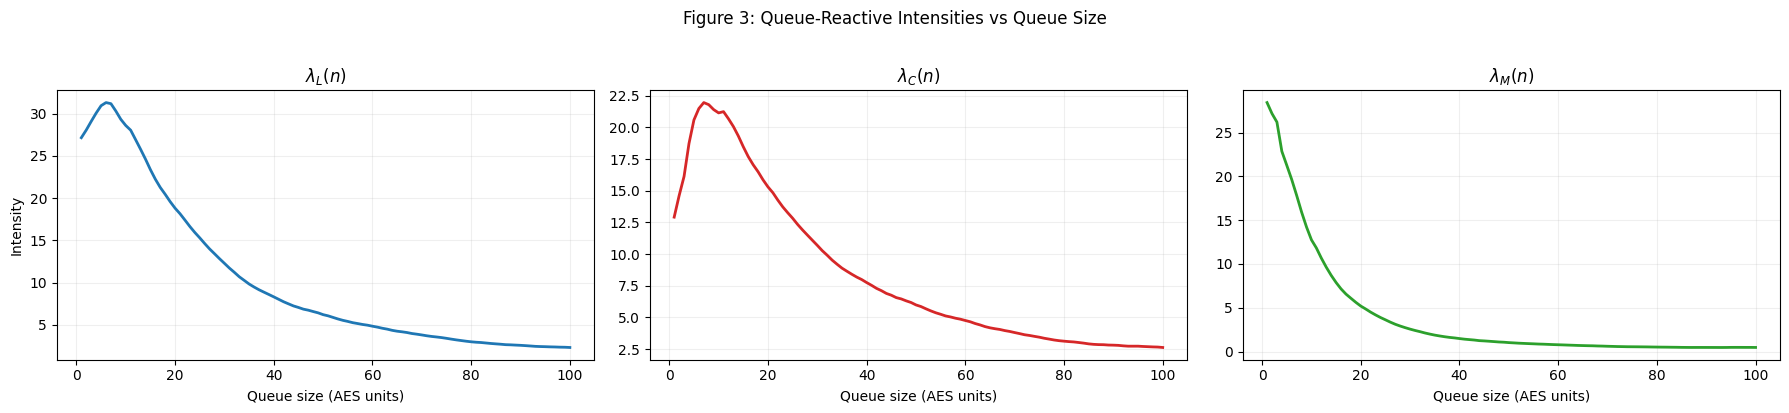

In [4]:
plot_cols = ["lambda_L", "lambda_C", "lambda_M"]
titles = [r"$\lambda_L(n)$", r"$\lambda_C(n)$", r"$\lambda_M(n)$"]
colors = ["#1f77b4", "#d62728", "#2ca02c"]
window = 5
n_plot_max = min(100, int(full_curves["n"].max()))

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for ax, col, title, color in zip(axes, plot_cols, titles, colors):
    plot_df = full_curves[full_curves["n"] <= n_plot_max].copy()
    plot_df[f"{col}_smooth"] = plot_df[col].rolling(window=window, min_periods=1, center=True).mean()
    ax.plot(plot_df["n"], plot_df[f"{col}_smooth"], color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Queue size (AES units)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Intensity")
fig.suptitle("Figure 3: Queue-Reactive Intensities vs Queue Size", y=1.02)
fig.tight_layout()

## Before vs After Occupancy Correction

The corrected state-duration estimator is compared against the old event-based estimator on the full month.

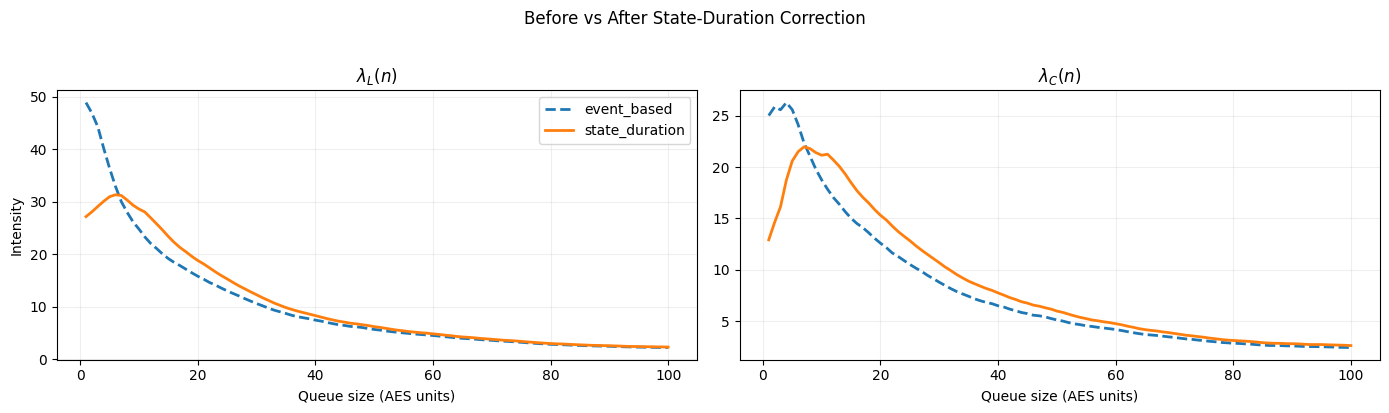

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for ax, col, title in zip(axes, ["lambda_L", "lambda_C"], [r"$\lambda_L(n)$", r"$\lambda_C(n)$"]):
    for estimator, style in [("event_based", "--"), ("state_duration", "-")]:
        plot_df = compare_curves[(compare_curves["estimator"] == estimator) & (compare_curves["n"] <= n_plot_max)].copy()
        plot_df[f"{col}_smooth"] = plot_df[col].rolling(window=window, min_periods=1, center=True).mean()
        ax.plot(plot_df["n"], plot_df[f"{col}_smooth"], linestyle=style, linewidth=2, label=estimator)
    ax.set_title(title)
    ax.set_xlabel("Queue size (AES units)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Intensity")
axes[0].legend()
fig.suptitle("Before vs After State-Duration Correction", y=1.02)
fig.tight_layout()

## Figure 4: Stability Across Time

The month is split into first-half and second-half trading days, and the two sets of intensity curves are overlaid.

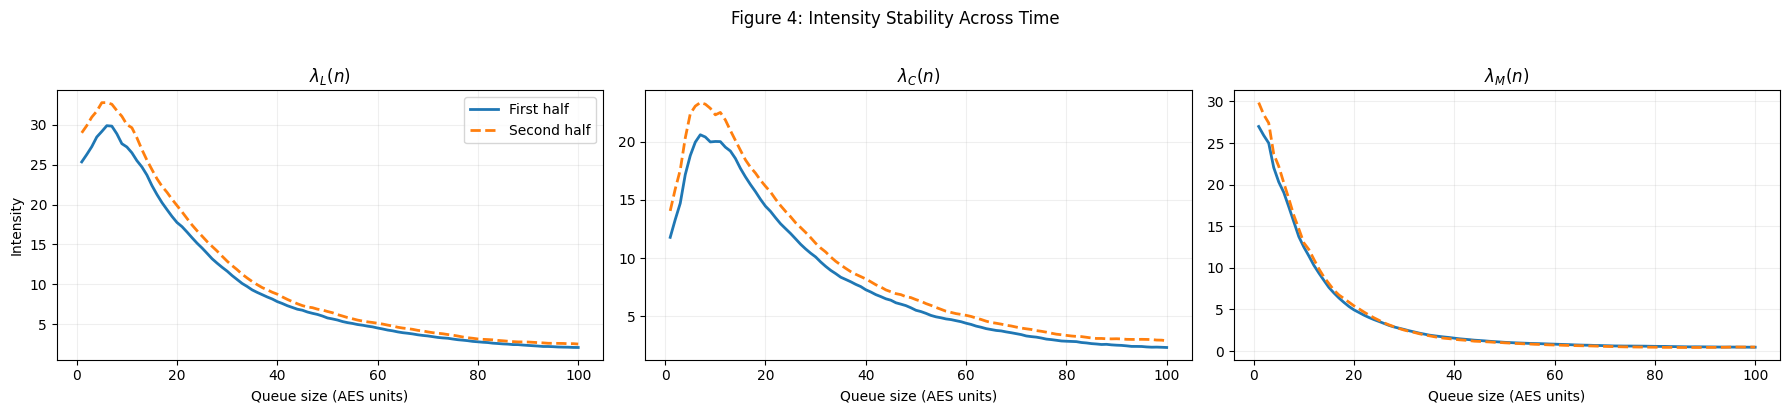

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for ax, col, title in zip(axes, plot_cols, titles):
    first_plot = first_curves[first_curves["n"] <= n_plot_max].copy()
    second_plot = second_curves[second_curves["n"] <= n_plot_max].copy()
    first_plot[f"{col}_smooth"] = first_plot[col].rolling(window=window, min_periods=1, center=True).mean()
    second_plot[f"{col}_smooth"] = second_plot[col].rolling(window=window, min_periods=1, center=True).mean()
    ax.plot(first_plot["n"], first_plot[f"{col}_smooth"], label="First half", linewidth=2)
    ax.plot(second_plot["n"], second_plot[f"{col}_smooth"], label="Second half", linewidth=2, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Queue size (AES units)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Intensity")
axes[0].legend()
fig.suptitle("Figure 4: Intensity Stability Across Time", y=1.02)
fig.tight_layout()

## Extended Model: Size-Dependent Intensities

The size-dependent table stores `lambda_(eta,s)(n)` so the extended Queue-Reactive specification can be inspected without recomputing the month.

In [7]:
full_size_curves = size_curves_df[(size_curves_df["segment"] == "full_month") & (size_curves_df["estimator"] == "state_duration")].copy()
display(full_size_curves.head(20))

top_size = (
    full_size_curves.groupby(["eta", "event_size"])["n_eta_size"]
    .sum()
    .reset_index()
    .sort_values("n_eta_size", ascending=False)
    .head(15)
)
display(top_size)

,n,eta,event_size,n_eta_size,lambda_eta_size,segment,date,estimator,n_obs,Lambda
0,1,C,1,357.950000,2.005659,full_month,NaN,state_duration,NaN,NaN
1,1,C,2,263.700000,1.570102,full_month,NaN,state_duration,NaN,NaN
2,1,C,3,461.050000,2.688293,full_month,NaN,state_duration,NaN,NaN
3,1,C,4,303.600000,1.733636,full_month,NaN,state_duration,NaN,NaN
4,1,C,5,80.050000,0.443744,full_month,NaN,state_duration,NaN,NaN
5,1,C,6,63.650000,0.394466,full_month,NaN,state_duration,NaN,NaN
6,1,C,7,37.450000,0.215306,full_month,NaN,state_duration,NaN,NaN
7,1,C,8,44.700000,0.272840,full_month,NaN,state_duration,NaN,NaN
8,1,C,9,25.050000,0.150185,full_month,NaN,state_duration,NaN,NaN
9,1,C,10,21.300000,0.124863,full_month,NaN,state_duration,NaN,NaN


,eta,event_size,n_eta_size
0,C,1,69197.899470
522,L,1,67017.672811
524,L,3,37680.462458
525,L,4,37252.133543
2,C,3,35197.621742
3,C,4,32124.365348
1152,M,1,29668.362927
1,C,2,27064.340078
523,L,2,24391.131565
527,L,6,17680.187753
